# The Basics

In [1]:
from IPython.display import HTML # ใช้สำหรับโชว์ HTML element


HTML("""
<iframe width="560" height="315" src="https://www.youtube.com/embed/myhC3s-8IG8" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>
""")

[Slides: The Basics 1](https://github.com/braincodecamp/brain-code-camp-2026-lectures/blob/main/DimensionalityReduction/dim_reduction_part1a_basics1.pdf)

<br>

Dimensionality reduction คือ การลดจำนวนมิติของข้อมูล

หากใช้ภาษาทางเทคนิค เราจะเรียกว่าเป็นการแปลงข้อมูลจากข้อมูลใน space ที่มีจำนวนมิติมาก (high-dimensional space) มาสู่ space ที่มีจำนวนมิติน้อย (low-dimensional space) ซึ่งเรามักจะออกแบบการลดจำนวนมิติลง โดยที่สูญเสียข้อมูลน้อยที่สุดเท่าที่ทำได้

ตัวอย่างของข้อมูลที่มีจำนวนมิติมาก


*   ข้อมูลรูปภาพ gray scale โดยที่แต่ละภาพมีจำนวน pixel เท่ากับ 1,024 x 1,024 = 1,048,576 pixels และเราใช้แต่ละ pixel เป็น feature แปลว่าในกรณีนี้ภาพ 1 ภาพ จะเป็นข้อมูล 1 จุดใน feature space ที่มี 1,048,576 มิติ (1,048,576-dimensional space)

*   ข้อมูล vdo ที่มีสี (แดง เขียว น้ำเงิน หรือ RGB) โดยเราสามารถมอง vdo เป็นรูปภาพจำนวนมากที่มาเรียงต่อกันได้ ถ้าหากแต่ละภาพใน vdo มี 1,024 x 1,024 pixels และเป็น vdo ความยาว 5 นาที ที่มี frame rate เท่ากับ 24 frame ต่อวินาที ข้อมูลของเราจะเป็นจุดใน space ที่มีทั้งหมด 1,024 x 1,024 x 3 x 24 x 5 x 60 มิติ หรือประมาณ 22 หมื่นล้านมิติ

*   ข้อมูลสัญญาณสมองที่เก็บมาจากเทคนิค electroencephalogram (EEG) ซึ่งมักจะมี sensor เก็บข้อมูลประมาณ 64 ตัว แต่ละตัวจะเก็บข้อมูลที่ประมาณ 1,000 จุดต่อวินาที ถ้าหากเราเก็บข้อมูลทั้งหมดเป็นเวลา 5 วินาที จะส่งผลให้ข้อมูลของเราอยู่ใน space ที่มีทั้งหมด 64 x 1,000 x 5 = 320,000 มิติ


ถ้าหากเราสามารถลดจำนวนมิติลงได้ จะส่งผลดีอยู่หลายประการ เช่น

1.   เราจะใช้ทรัพยากรการคำนวณน้อยลง เช่น ถ้าหากเราสามารถ represent ภาพ 1 ภาพ ด้วยตัวเลขแค่ 64 ตัว (แทนที่จะ represent ด้วยตัวเลข 1,048,576 ตัว) เราก็จะสามารถนำเอาโมเดลปัญญาประดิษฐ์ที่เรารู้จักมาประมวลผลได้อย่างรวดเร็วและใช้ทรัพยากรการคำนวณน้อย

2.   นอกจากนี้ หากเราลดจำนวนมิติของข้อมูลลงจนเหลือไม่เกิน 3 มิติ ก็จะช่วยให้เราสามารถนำเอาข้อมูลมา plot และดูได้ด้วยตาเปล่า

ในการลดจำนวนมิติของข้อมูล เราสามารถใช้ทั้งเทคนิคที่เป็นแบบ linear หรือ แบบ non-linear ก็ได้ โดยที่แต่ละเทคนิคก็จะมีข้อดีและข้อเสีย และมีสมมติฐานในการใช้งานที่แตกต่างกัน

In [2]:
HTML("""
<iframe width="560" height="315" src="https://www.youtube.com/embed/p127ONwUOSg" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>
""")

[Slides: The Basics 2](https://github.com/braincodecamp/brain-code-camp-2026-lectures/blob/main/DimensionalityReduction/dim_reduction_part1b_basics2.pdf)

<br>

สมมติว่าเรามีชุดข้อมูลชุดหนึ่ง ที่มีจุดข้อมูลอยู่ทั้งหมด 100 จุด แต่ละจุดข้อมูล $(x,y)$ เป็นข้อมูลใน space ที่มี 2 มิติ (ค่า $x$ เป็นมิติแรก และค่า $y$ เป็นมิติที่สอง) และในชุดข้อมูลนี้มีจุดอยู่ 2 ประเภท (2 classes)


*   class 1: $y = 1$ โดยที่ $ -4 ≤ x < 0 $
*   class 2: $y = 1$ โดยที่ $ 0 < x ≤ 4 $

ดังแสดงด้านล่าง

In [3]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib import colors

import ipywidgets as widgets  # ใช้สำหรับการทำ interactive display

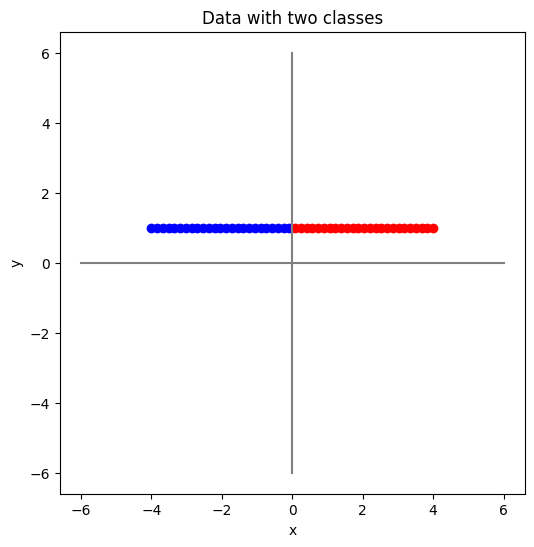

In [4]:
num_points = 50 # # จำนวนจุดข้อมูล
x = np.linspace(-4, 4, num_points)
y = 1

# นำเอาค่า x มาใส่ใน column แรกของ data matrix และ ค่า y มาใส่ใน column ที่สอง
data = np.zeros((num_points, 2))
data[:, 0] = x
data[:, 1] = y

# เตรียมแสดงผล
x_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ x สำหรับแสดงผล
y_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ y สำหรับแสดงผล

plt.figure(figsize=(6, 6))

# แสดงรูปข้อมูลเริ่มต้น
plt.scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
plt.scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
plt.plot([0, 0], y_disp, c="grey") # Plot แกน y
plt.plot(x_disp, [0, 0], c="grey") # Plot แกน x
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data with two classes")
plt.show()

ถ้าหากเราต้องการแก้โจทย์ two-class classification หรือ แบ่งจุดข้อมูลที่เรามีออกเป็น 2 ประเภท (ประเภทน้ำเงิน และ ประเภทสีแดง) โดยที่เราใช้ค่า $x$ เป็น feature แรก และใช้ค่า $y$ เป็น feature ที่สอง เราสามารถใช้แกน $y$ (สมการคือ $ x=0$) แบ่งข้อมูลทั้ง 2 ประเภทออกจากกันได้เลย โดยเราจะตอบว่าจุดข้อมูลนั้นเป็น

1. class 1 (ประเภทที่ 1) ถ้าหากจุดนั้นมีค่า $x$ น้อยกว่า $0$ หรือถ้าดูจากภาพก็คือจุดนั้นอยู่ทางซ้ายของแกน $y$
2.   class 2 (ประเภทที่ 2) ถ้าหากจุดนั้นมีค่า $x$ มากกว่า $0$ หรือถ้าดูจากภาพก็คือจุดนั้นอยู่ทางขวาของแกน $y$

จะเห็นว่าเราสามารถแบ่งจุดข้อมูลสองกลุ่มนี้ได้อย่างง่ายดาย โดยการดูแค่ค่า $x$ อย่างเดียว โดยที่ไม่ต้องสนใจค่า $y$ ซึ่งแปลว่าเราจริง ๆ แล้ว เราสามารถลดข้อมูลมิติของข้อมูลจากสองมิติ ($x$ หนึ่งมิติ และ $y$ เป็นอีกมิติ) ให้เหลือแค่มิติเดียว (ค่า $x$ เพียงอย่างเดียว) ก็ยังสามารถ classify จุดเหล่านี้ได้เหมือนเดิม ดังแสดงในภาพด้านล่าง


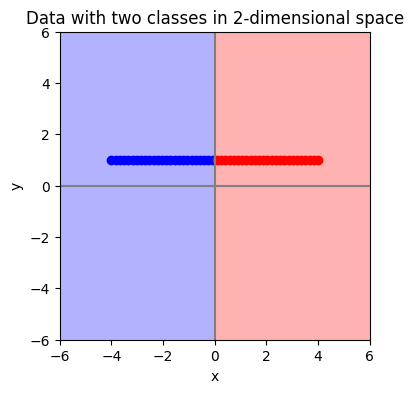

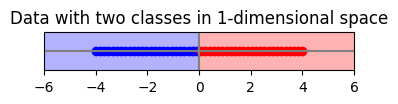

In [5]:
x_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ x สำหรับแสดงผล
y_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ y สำหรับแสดงผล

# สร้างจุด (x,y) จำนวนมาก สำหรับเอามาใช้แสดงผล classification ที่จุดต่าง ๆ โดยใช้สีน้ำเงินแดง class 1 และสีแดงแสดง class 2
xx, yy = np.meshgrid(np.linspace(x_disp[0], x_disp[1], 100), np.linspace(y_disp[0], y_disp[1], 100))

# เก็บข้อมูลว่าแต่ละจุดถูก classify เป็น class อะไรบ้าง โดยใช้เลข 0 สำหรับ class 1 และ 1 สำหรับ class 2
labels_predicted = (xx.ravel() > 0).reshape(xx.shape)

# Plot ข้อมูลในสองมิติ
plt.figure(figsize=(4, 4))
plt.scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1 ด้วยสีน้ำเงิน
plt.scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2 ด้วนสีแดง
plt.plot([0, 0], y_disp, c="grey") # Plot แกน y
plt.plot(x_disp, [0, 0], c="grey") # Plot แกน x
plt.pcolormesh(xx, yy, labels_predicted, cmap=colors.ListedColormap(["blue", "red"]), norm=colors.Normalize(0.0, 1.0), zorder=0, alpha=0.3) # Plot ผลจากทำนายจากข้อมูล xx และ yy
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(x_disp)
plt.ylim(y_disp)
plt.title("Data with two classes in 2-dimensional space")

# Plot ข้อมูลที่ลดมิติมาแล้ว
plt.figure(figsize=(4, 0.5))
plt.scatter(data[data[:, 0] < 0, 0], np.zeros_like(data[data[:, 0] < 0, 0]), c='b') # Plot จุดข้อมูลที่เป็น class 1
plt.scatter(data[data[:, 0] > 0, 0], np.zeros_like(data[data[:, 0] > 0, 0]), c='r') # Plot จุดข้อมูลที่เป็น class 2
plt.plot([0, 0], y_disp, c="grey") # Plot แกน y
plt.plot(x_disp, [0, 0], c="grey") # Plot แกน x
plt.pcolormesh(xx, yy, labels_predicted, cmap=colors.ListedColormap(["blue", "red"]), norm=colors.Normalize(0.0, 1.0), zorder=0, alpha=0.3) # Plot ผลจากทำนายจากข้อมูล xx เพึยงอย่างเดียว
plt.xlim(x_disp)
plt.ylim(-0.5, 0.5)
plt.title("Data with two classes in 1-dimensional space")
plt.yticks([])
plt.show()

ตัวอย่างด้านบนแสดงให้เห็นว่าในบางชุดข้อมูล เราสามารถลดจำนวนมิติของข้อมูลได้ โดยที่ยังมีความสามารถในการทำ classification ได้เหมือนเดิม

---

ตัวอย่างถัดมา สมมติว่าเรามีชุดข้อมูลชุดหนึ่ง ที่มีจุดข้อมูลอยู่ทั้งหมด 100 จุด แต่ละจุดข้อมูล $(x,y)$ เป็นข้อมูลใน space ที่มี 2 มิติ (ค่า $x$ เป็นมิติแรก และค่า $y$ เป็นมิติที่สอง) และในชุดข้อมูลนี้มีจุดอยู่ 2 ประเภท (2 classes)


*   class 1: $y = x$ โดยที่ $ -4 ≤ x < 0 $
*   class 2: $y = x$ โดยที่ $ 0 < x ≤ 4 $

ดังแสดงด้านล่าง

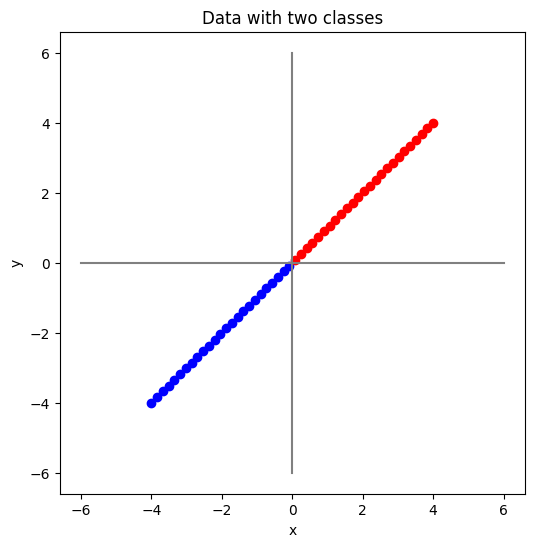

In [6]:
num_points = 50
x = np.linspace(-4, 4, num_points)
y = x
data = np.zeros((num_points, 2))
data[:, 0] = x
data[:, 1] = y

# เตรียมแสดงผล
x_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ x สำหรับแสดงผล
y_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ y สำหรับแสดงผล

plt.figure(figsize=(6, 6))

# แสดงรูปข้อมูลเริ่มต้น
plt.scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
plt.scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
plt.plot([0, 0], y_disp, c="grey") # Plot แกน y
plt.plot(x_disp, [0, 0], c="grey") # Plot แกน x
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data with two classes")
plt.show()

จะเห็นว่าถ้าเรานำเอาข้อมูลด้านบนแต่ละจุดมาหมุนตามเข็มนาฬิกาไป $45$ องศา โดยมีจุด $(0,0)$ เป็นจุดหมุน เราจะสามารถแปลงโจทย์ข้อนี้ให้กลายเป็นโจทย์ที่มีหน้าตาคล้ายกับข้อมูลในตัวอย่างก่อนหน้า

การหมุนจุดข้อมูลทวนเข็มนาฬิกาไป $\theta$ องศาโดยมีจุด $(0,0)$ เป็นจุดหมุน สามารถอธิบายได้ด้วย rotation matrix

$$
  R(θ) =
  \begin{bmatrix}
      cos θ        & -sin θ  \\
      sin θ       & cos θ \\
  \end{bmatrix}
$$

หากเรา represent พิกัด $(x,y)$ ด้วย vector

$$
  \begin{bmatrix}
      x \\
      y\\
  \end{bmatrix}
$$

เราจะสามารถหมุนจุดข้อมูลนั้นตามเข็มนาฬิกา 45 องศา ด้วยการใช้ $R(-45°)$



$$
   \begin{bmatrix}
      x' \\
      y'\\
  \end{bmatrix} =
  R(-45°)  \begin{bmatrix}
      x \\
      y\\
  \end{bmatrix}
$$

เกิดเป็นพิกัด $(x',y')$

ก่อนอื่นเรามาลองเล่นดูใน widget นี้ว่าเมื่อเปลี่ยน องศา แล้วข้อมูลจะเปลี่ยนไปอย่างไรบ้าง

In [7]:
HTML("""
<!DOCTYPE html>
<html>
<head>
  <style>
    canvas {
      border: 1px solid black;
    }
  </style>
</head>
<body>
  <input type="range" id="angleSlider" min="-180" max="180" value="0" step="1">
  <div id="angleValue"></div>
  <div id="transformationMatrix"></div>
  <canvas id="canvas"></canvas>
  <script>
    // Generate x and y data points from Python code
    const numPoints = 50;
    const x = [-2.8284271247461903,-2.7129811169126663,-2.5975351161502105,-2.4820891083166865,-2.3666431075542302,-2.2511970997207067,-2.1357510918871827,-2.020305091124727,-1.9048590832912027,-1.789413075457679,-1.6739670746952229,-1.5585210668616991,-1.4430750660992433,-1.3276290582657193,-1.2121830504321953,-1.0967370496697393,-0.9812910418362154,-0.8658450410737594,-0.7503990332402356,-0.6349530254067116,-0.5195070246442557,-0.4040610168107318,-0.2886150160482758,-0.17316900821475187,-0.057723000381228025,0.057723000381228025,0.17316900821475187,0.2886150160482758,0.4040610168107318,0.5195070246442557,0.6349530254067116,0.7503990332402356,0.8658450410737594,0.9812910418362154,1.0967370496697393,1.2121830504321953,1.3276290582657193,1.4430750660992433,1.5585210668616991,1.6739670746952229,1.789413075457679,1.9048590832912027,2.020305091124727,2.1357510918871827,2.2511970997207067,2.3666431075542302,2.4820891083166865,2.5975351161502105,2.7129811169126663,2.8284271247461903];
    const y = [-2.82842712474619,-2.7129811169126663,-2.59753511615021,-2.482089108316686,-2.3666431075542302,-2.2511970997207063,-2.1357510918871827,-2.0203050911247264,-1.9048590832912025,-1.7894130754576787,-1.6739670746952227,-1.558521066861699,-1.4430750660992429,-1.327629058265719,-1.212183050432195,-1.096737049669739,-0.9812910418362152,-0.8658450410737593,-0.7503990332402355,-0.6349530254067116,-0.5195070246442556,-0.40406101681073175,-0.2886150160482757,-0.17316900821475184,-0.05772300038122801,0.05772300038122801,0.17316900821475184,0.2886150160482757,0.40406101681073175,0.5195070246442556,0.6349530254067116,0.7503990332402355,0.8658450410737593,0.9812910418362152,1.096737049669739,1.212183050432195,1.327629058265719,1.4430750660992429,1.558521066861699,1.6739670746952227,1.7894130754576787,1.9048590832912025,2.0203050911247264,2.1357510918871827,2.2511970997207063,2.3666431075542302,2.482089108316686,2.59753511615021,2.7129811169126663,2.82842712474619];

    // Combine x and y data into points array
    const points = x.map((xVal, index) => ({
      x: xVal * 50, // Scale x values to fit canvas
      y: y[index] * 50, // Scale y values to fit canvas
      original: true // Flag to indicate original points
    }));

    // Get the angle slider element
    const angleSlider = document.getElementById('angleSlider');

    // Get the value display elements
    const angleValue = document.getElementById('angleValue');
    const transformationMatrix = document.getElementById('transformationMatrix');

    // Get the canvas element
    const canvas = document.getElementById('canvas');
    const context = canvas.getContext('2d');

    // Function to update the rotation based on the slider value
    function updateRotation() {
      // Angle in degrees
      const theta = angleSlider.value;

      // Convert angle to radians
      const thetaRad = (theta * Math.PI) / 180;

      // Rotation matrix
      const cosTheta = Math.cos(thetaRad);
      const sinTheta = Math.sin(thetaRad);
      const rotationMatrix = [
        cosTheta, -sinTheta,
        sinTheta, cosTheta
      ];

      // Apply rotation transformation to each point
      const rotatedPoints = points.map(point => ({
        x: (point.x * rotationMatrix[0]) + (point.y * rotationMatrix[1]),
        y: (point.x * rotationMatrix[2]) + (point.y * rotationMatrix[3]),
        original: point.original
      }));

      // Find the maximum distance between the points
      const distances = rotatedPoints.map(point => Math.sqrt(point.x ** 2 + point.y ** 2));
      const maxDistance = Math.max(...distances);

      // Calculate the canvas dimensions based on the maximum distance
      const canvasSize = 2 * maxDistance + 20; // Add some padding

      // Update canvas dimensions
      canvas.width = canvasSize;
      canvas.height = canvasSize;

      // Calculate the center of the canvas
      const centerX = canvas.width / 2;
      const centerY = canvas.height / 2;

      // Adjust the points to be relative to the center
      const adjustedPoints = rotatedPoints.map(point => ({
        x: centerX + point.x,
        y: centerY - point.y, // Subtract to invert the y-axis
        original: false
      }));

      const adjustedOriginalPoints = points.map(point => ({
        x: centerX + point.x,
        y: centerY - point.y, // Subtract to invert the y-axis
        original: true
      }));

      // Clear canvas
      context.clearRect(0, 0, canvas.width, canvas.height);

      // Draw axes
      context.beginPath();
      context.moveTo(centerX, 0);
      context.lineTo(centerX, canvas.height);
      context.moveTo(0, centerY);
      context.lineTo(canvas.width, centerY);
      context.strokeStyle = 'gray';
      context.stroke();

      // Draw points
      adjustedOriginalPoints.forEach((point, i) => {
        let alpha = 0.1;

        if (i < numPoints/2) {
          context.fillStyle = `rgba(0, 0, 255, ${alpha})`; // First half of rotated points with blue color
        } else {
          context.fillStyle = `rgba(255, 0, 0, ${alpha})`; // Second half of rotated points with red color
        }
        context.beginPath();
        context.arc(point.x, point.y, 4, 0, 2 * Math.PI);
        context.fill();
      });

      adjustedPoints.forEach((point, i) => {
        let alpha = 1;

        if (i < numPoints/2) {
          context.fillStyle = `rgba(0, 0, 255, ${alpha})`; // First half of rotated points with blue color
        } else {
          context.fillStyle = `rgba(255, 0, 0, ${alpha})`; // Second half of rotated points with red color
        }
        context.beginPath();
        context.arc(point.x, point.y, 4, 0, 2 * Math.PI);
        context.fill();
      });

      // Update angle value display
      angleValue.textContent = `Angle: ${theta}°`;

      // Update transformation matrix display
      transformationMatrix.innerHTML = `
        <table>
          <tr>
            <td>${rotationMatrix[0].toFixed(2)}</td>
            <td>${rotationMatrix[1].toFixed(2)}</td>
          </tr>
          <tr>
            <td>${rotationMatrix[2].toFixed(2)}</td>
            <td>${rotationMatrix[3].toFixed(2)}</td>
          </tr>
        </table>
      `;
    }

    // Add event listener to the angle slider
    angleSlider.addEventListener('input', updateRotation);

    // Initial rotation update
    updateRotation();
  </script>
</body>
</html>
""")

ตอนนี้เรามาลองหมุนข้อมูลกันโดยใช้ code ใน cell ถัดมากันดีกว่า

In [8]:
def rotate_counterclockwise(data, degree):

    # สร้าง rotation matrix R ที่ทำหน้าที่ใช้หมุนพิกัดทวนเข็มนาฬิกา
    R = np.array([[np.cos(degree), -np.sin(degree)],
                  [np.sin(degree), np.cos(degree)]])

    return np.transpose(np.matmul(R, np.transpose(data)))


@widgets.interact(angle_counter_clock_degree=widgets.IntSlider(0, min=-180, max=180, description='Angle (deg)'),
                  show_original=widgets.Checkbox(True, description='Show original data'))
def plot_rotated_results(angle_counter_clock_degree, show_original):

    # ทำการหมุนข้อมูล
    data_rot = rotate_counterclockwise(data, angle_counter_clock_degree*(np.pi/180))

    # สร้าง figure
    fig, ax = plt.subplots(figsize=(6,6))

    # Plot ข้อมูล x, y ที่มีอยู่ด้วยสีน้ำเงิน
    ax.scatter(data_rot[data[:, 0] < 0, 0], data_rot[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
    ax.scatter(data_rot[data[:, 0] > 0, 0], data_rot[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
    ax.plot([0, 0], [-6.0, 6.0], c="m", alpha=0.5) # Plot แกน y ที่ถูกหมุน
    ax.plot([-6.0, 6.0], [0, 0], c="m", alpha=0.5) # Plot แกน x ที่ถูกหมุน


    if show_original:
        ax.scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b', alpha=0.1) # Plot จุดข้อมูลที่เป็น class 1
        ax.scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r', alpha=0.1) # Plot จุดข้อมูลที่เป็น class 2

    ax.set_title(f"Data rotated by {angle_counter_clock_degree} degrees (counter-clockwise centered at (0,0))")
    plt.show()

interactive(children=(IntSlider(value=0, description='Angle (deg)', max=180, min=-180), Checkbox(value=True, d…

เรามาลองดูว่า ถ้าหมุนจุดข้อมูลเหล่านี้ตามเข็มนาฬิกาไป 45 องศา โดยมีจุดหมุนคือ $(0,0)$ ผลจะเป็นอย่างไร

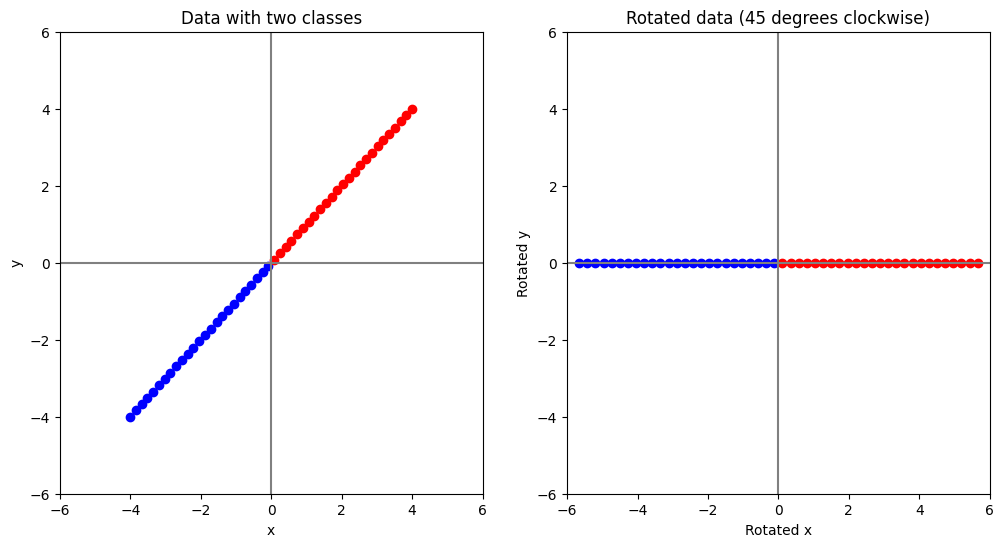

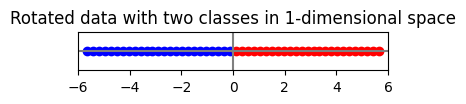

In [9]:
# ใช้ rotation matrix คำนวณพิกัดใหม่ของจุดทั้งหมด
data_rot45 = rotate_counterclockwise(data, -np.pi/4)

# เตรียมแสดงผล
x_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ x สำหรับแสดงผล
y_disp = [-6.0, 6.0] # ค่าต่ำสูงและสูงสุดของ y สำหรับแสดงผล

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# แสดงรูปข้อมูลเริ่มต้น
ax[0].scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[0].scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[0].plot([0, 0], y_disp, c="grey") # Plot แกน y
ax[0].plot(x_disp, [0, 0], c="grey") # Plot แกน x
ax[0].set(xlabel="x", ylabel="y")
ax[0].set_title("Data with two classes")


# แสดงรูปหลังหมุนข้อมูลตามเข็มนาฬิกาไป 45 องศา
ax[1].scatter(data_rot45[data[:, 0] < 0, 0], data_rot45[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[1].scatter(data_rot45[data[:, 0] > 0, 0], data_rot45[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[1].plot([0, 0], y_disp, c="grey") # Plot แกน y
ax[1].plot(x_disp, [0, 0], c="grey") # Plot แกน x
ax[1].set(xlabel="Rotated x", ylabel="Rotated y")
ax[1].set_title("Rotated data (45 degrees clockwise)")

plt.setp(ax, xlim=x_disp, ylim=y_disp)

# Plot ข้อมูลที่ลดมิติมาแล้ว
plt.figure(figsize=(4, 0.5))
plt.scatter(data_rot45[data[:, 0] < 0, 0], np.zeros_like(data_rot45[data[:, 0] < 0, 0]), c='b') # Plot จุดข้อมูลที่เป็น class 1
plt.scatter(data_rot45[data[:, 0] > 0, 0], np.zeros_like(data_rot45[data[:, 0] > 0, 0]), c='r') # Plot จุดข้อมูลที่เป็น class 2
plt.plot([0, 0], y_disp, c="grey") # Plot แกน y
plt.plot(x_disp, [0, 0], c="grey") # Plot แกน x
plt.xlim(x_disp)
plt.ylim(-0.5, 0.5)
plt.title("Rotated data with two classes in 1-dimensional space")
plt.yticks([])
plt.show()


plt.show()

มีข้อสังเกตดังนี้


*   ข้อมูลเริ่มต้นอยู่ใน space ขนาด 2 มิติ โดยมีลักษณะเป็นเส้นตรงที่ทำมุม $45$ องศากับแกน $x$

*   ถ้าหากเราหมุนจุดข้อมูลเหล่านั้นตามเข็มนาฬิกาไป $45$ องศา เราจะเห็นข้อมูลจัดเรียงกันอยู่บนแกน $x$ โดยที่ค่าใน แกน $y$ ทุกตัวเป็น $0$

* ถ้าหากเราต้องการจะ classify ข้อมูลนี้ เราสามารถทำได้โดยการดูแค่ค่าในแกน $x$ (ไม่ต้องดูแกน $y$ เลย) แสดงว่าเราสามารถลดจำนวนมิติของข้อมูลให้เหลือ $1$ มิติได้ โดยที่ยังมีความสามารถในการทำ classification ได้เหมือนเดิม

<br><br>

จะเห็นได้ว่าในหลาย ๆ ครั้ง เราสามารถลดจำนวนมิติได้  ซึ่งในตัวอย่างเหล่านี้เราแค่ใช้การ transform จุดข้อมูลอย่างง่าย เช่น การหมุน ก็ส่งผลให้ข้อมูลมาอยู่ในรูปแบบที่เราสามารถกำจัดแกน $y$ ได้เลย ส่งผลให้จำนวนมิติลดลงจาก 2 มิติ ไปเป็น 1 มิติ
และเรายังพบว่าเราสามารถนำเอาข้อมูลใน 1 มิตินี้ไปใช้งานต่อได้ เช่น เรายังสามารถนำเอาไปใช้เป็น feature ในการ classify ได้เหมือนเดิม

---



**ข้อสังเกต** ในตัวอย่างล่าสุด เราหมุนจุดข้อมูลไป $45$ องศาแบบตามเข็มนาฬิกา โดยที่ไม่ขยับแกน $x$ และ แกน $y$ เลย ซึ่งการทำแบบนี้ ในอีกมุมมองนึง ก็เหมือนกับการหมุนแกน $x$ และ แกน $y$ ไป $45$ องศาแบบทวนเข็มนาฬิกา โดยที่ไม่ขยับจุดข้อมูล ซึ่งเราจะใช้สีชมพูเข้มแสดงแกน $x$ ที่ถูกหมุน และ สีชมพูอ่อนแสดงแกน $y$ ที่ถูกหมุน (แล้วเอียงศีรษะไป $45$ องศาทวนเข็มนาฬิกาขณะดูภาพ) ดังแสดงด้วยตัวอย่าง code ใน cell ถัดมา

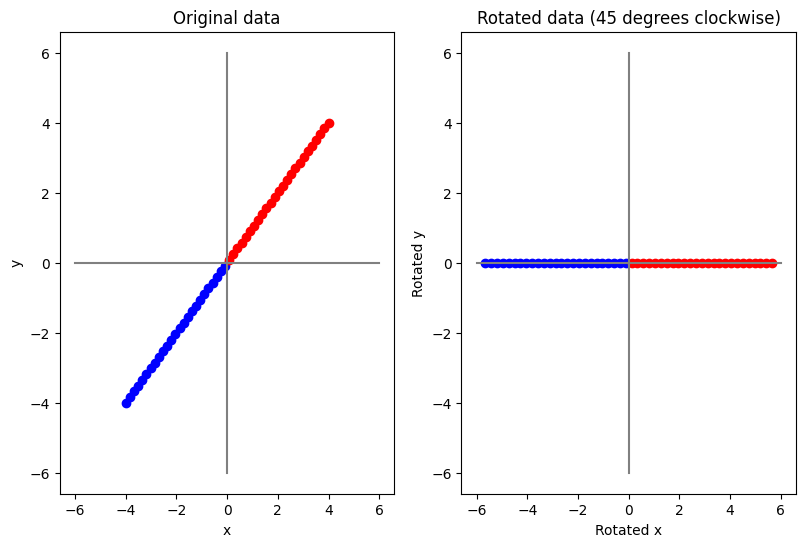

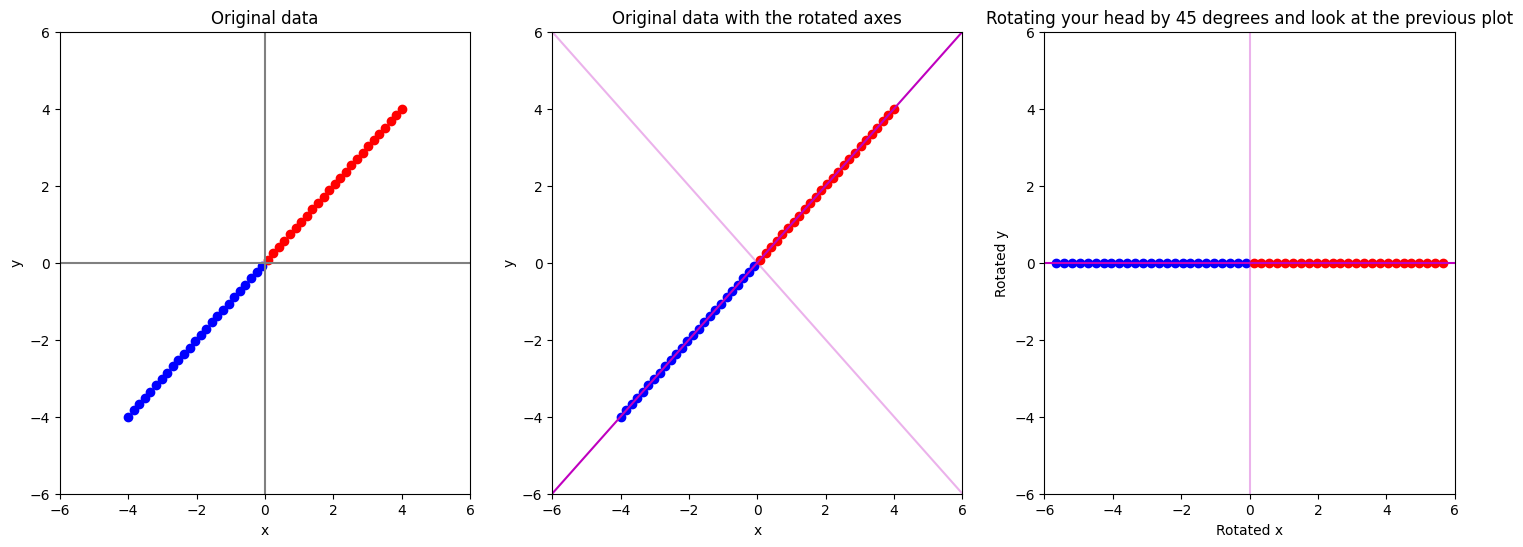

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 6))

# แสดงรูปข้อมูลเริ่มต้น
ax[0].scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[0].scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[0].plot([0, 0], y_disp, c="grey") # Plot แกน y
ax[0].plot(x_disp, [0, 0], c="grey") # Plot แกน x
ax[0].set(xlabel="x", ylabel="y")
ax[0].set_title("Original data")


# แสดงรูปหลังหมุนข้อมูลตามเข็มนาฬิกาไป 45 องศา
ax[1].scatter(data_rot45[data[:, 0] < 0, 0], data_rot45[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[1].scatter(data_rot45[data[:, 0] > 0, 0], data_rot45[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[1].plot([0, 0], y_disp, c="grey") # Plot แกน y
ax[1].plot(x_disp, [0, 0], c="grey") # Plot แกน x
ax[1].set(xlabel="Rotated x", ylabel="Rotated y")
ax[1].set_title("Rotated data (45 degrees clockwise)")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# แสดงรูปข้อมูลเริ่มต้น
ax[0].scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[0].scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[0].plot([0, 0], y_disp, c="grey") # Plot แกน y
ax[0].plot(x_disp, [0, 0], c="grey") # Plot แกน x
ax[0].set(xlabel="x", ylabel="y")
ax[0].set_title("Original data")

# แสดงรูปข้อมูลที่มีการหมุนแกนทวนเข็มนาฬิการไป 45 องศา

# แสดงรูปข้อมูลเริ่มต้นโดยมี principal component ทั้ง 2 อันแสดงอยู่ด้วย
ax[1].scatter(data[data[:, 0] < 0, 0], data[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[1].scatter(data[data[:, 0] > 0, 0], data[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[1].plot(x_disp, [x_disp[0], x_disp[1]], c="m", alpha=1) # แสดง pc1 โดยใช้สมการ y = x
ax[1].plot(x_disp, [-x_disp[0], -x_disp[1]], c="m", alpha=0.3) # แสดง pc2 โดยใช้สมการ y = -x
ax[1].set(xlabel='x', ylabel='y')
ax[1].set_title("Original data with the rotated axes")

# แสดงข้อมูลที่หมุนแกนและเอียงศีรษะดู
ax[2].scatter(data_rot45[data[:, 0] < 0, 0], data_rot45[data[:, 0] < 0, 1], c='b') # Plot จุดข้อมูลที่เป็น class 1
ax[2].scatter(data_rot45[data[:, 0] > 0, 0], data_rot45[data[:, 0] > 0, 1], c='r') # Plot จุดข้อมูลที่เป็น class 2
ax[2].plot(x_disp, [0, 0], c="m", alpha=1)
ax[2].plot([0, 0], y_disp, c="m", alpha=0.3)
ax[2].set(xlabel="Rotated x", ylabel="Rotated y")
ax[2].set_title("Rotating your head by 45 degrees and look at the previous plot")

plt.setp(ax, xlim=x_disp, ylim=y_disp)
plt.show()

<br><br>

ในสถานการณ์การทำงานจริง เรามักเจอข้อมูลที่มีความซับซ้อนมาก เช่น ข้อมูลที่อยู่ใน space ที่มีจำนวนมิติสูงมาก เราอาจจะไม่สามารถใช้การ transform แบบง่าย ๆ ที่เราใช้ในตัวอย่างนี้ จึงมีเทคนิคมากมายถูกคิดค้นขึ้นเพื่อใช้ช่วยลดมิติของข้อมูลของเราได้อย่างมีประสิทธิภาพ

**ผู้จัดเตรียม code ใน tutorial**: ดร. อิทธิ ฉัตรนันทเวช และ ดร. สุรัฐ ธีรพิทยานนท์